## Notebook 02 -- Construction de la Variable Cible (Qualite de l'Air)

### Objectif

Collecter les donnees de qualite de l'air (PM2.5, PM10, NO2, O3, CO, SO2) pour les 42 villes camerounaises sur la periode **2020-01-01 a 2025-12-31**.

### Strategie de collecte

1. **Source principale : Open-Meteo Air Quality API** -- Donnees horaires CAMS disponibles historiquement. Couvre l'ensemble de la periode 2020-2025.
2. **Source complementaire : CAMS EAC4 (Copernicus ADS)** -- Utilisee uniquement pour combler les lacunes eventuelles d'Open-Meteo sur 2020-2024.

### Polluants collectes

| Variable | Description | Unite |
|----------|-------------|-------|
| PM2.5 | Particules fines < 2.5 um | ug/m3 |
| PM10 | Particules < 10 um | ug/m3 |
| NO2 | Dioxyde d'azote | ug/m3 |
| O3 | Ozone | ug/m3 |
| CO | Monoxyde de carbone | ug/m3 |
| SO2 | Dioxyde de soufre | ug/m3 |

Le fichier de sortie `air_quality_targets.parquet` sera joint au dataset meteorologique nettoye dans le notebook de modelisation.

In [1]:
## --- [SECTION 1] : Imports et constantes --- ##

import requests
import pandas as pd
import numpy as np
import time as time_module
import json
import logging
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

# Configuration du logger
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%H:%M:%S'
)
logger = logging.getLogger(__name__)

# Style graphique
sns.set_style('whitegrid')
sns.set_palette('colorblind')
plt.rcParams.update({
    'figure.figsize': (14, 8),
    'figure.dpi': 100,
    'font.size': 11,
})

# --- Constantes --- #

# Periode globale
DATE_START = '2020-01-01'
DATE_END   = '2025-12-31'

# Source principale : Open-Meteo Air Quality API (2020-2025)
OPENMETEO_URL = 'https://air-quality-api.open-meteo.com/v1/air-quality'

# Variables Open-Meteo Air Quality (concentrations horaires)
AQ_VARIABLES = [
    'pm2_5', 'pm10', 'nitrogen_dioxide', 'ozone', 'carbon_monoxide', 'sulphur_dioxide',
    # AQI US EPA precalcules par Open-Meteo (moyennes glissantes correctes)
    'us_aqi', 'us_aqi_pm2_5', 'us_aqi_pm10', 'us_aqi_ozone',
    'us_aqi_nitrogen_dioxide', 'us_aqi_carbon_monoxide', 'us_aqi_sulphur_dioxide',
]

# Variables AQI Open-Meteo (pour agregation et traitement specifique)
AQI_OM_VARIABLES = [
    'us_aqi', 'us_aqi_pm2_5', 'us_aqi_pm10', 'us_aqi_ozone',
    'us_aqi_nitrogen_dioxide', 'us_aqi_carbon_monoxide', 'us_aqi_sulphur_dioxide',
]

# Noms courts pour les colonnes finales
AQ_SHORT_NAMES = {
    'pm2_5': 'pm2_5',
    'pm10': 'pm10',
    'nitrogen_dioxide': 'no2',
    'ozone': 'o3',
    'carbon_monoxide': 'co',
    'sulphur_dioxide': 'so2',
}

SLEEP_SEC   = 1.0
MAX_RETRIES = 3

# Repertoires
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUTPUT_DIR  = PROJECT_DIR / 'data'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Source complementaire : CAMS EAC4 via Copernicus ADS (fallback)
CAMS_AVAILABLE = False
try:
    import cdsapi
    import xarray as xr
    CAMS_AVAILABLE = True
    ADS_DATASET = 'cams-global-reanalysis-eac4'
    CAMEROON_BBOX = [13.5, 8.0, 1.5, 16.5]
    logger.info('[OK] cdsapi et xarray disponibles -- CAMS EAC4 utilisable en fallback.')
except ImportError:
    logger.info('[INFO] cdsapi/xarray non installes -- CAMS EAC4 desactive (Open-Meteo uniquement).')

# Dictionnaire des 42 villes camerounaises
VILLES = {
    'Bafia':         {'lat': 4.7500,  'lon': 11.2333, 'region': 'Centre'},
    'Akonolinga':    {'lat': 3.7667,  'lon': 12.2500, 'region': 'Centre'},
    'Yaounde':       {'lat': 3.8667,  'lon': 11.5167, 'region': 'Centre'},
    'Mbalmayo':      {'lat': 3.5167,  'lon': 11.5000, 'region': 'Centre'},
    'Tibati':        {'lat': 6.4667,  'lon': 12.6333, 'region': 'Adamaoua'},
    'Tignere':       {'lat': 7.3667,  'lon': 12.6500, 'region': 'Adamaoua'},
    'Ngaoundere':    {'lat': 7.3167,  'lon': 13.5833, 'region': 'Adamaoua'},
    'Meiganga':      {'lat': 6.5167,  'lon': 14.2833, 'region': 'Adamaoua'},
    'Bertoua':       {'lat': 4.5833,  'lon': 13.6833, 'region': 'Est'},
    'Abong-Mbang':   {'lat': 3.9833,  'lon': 13.1667, 'region': 'Est'},
    'Batouri':       {'lat': 4.4333,  'lon': 14.3667, 'region': 'Est'},
    'Yokadouma':     {'lat': 3.5167,  'lon': 15.0500, 'region': 'Est'},
    'Maroua':        {'lat': 10.5908, 'lon': 14.3159, 'region': 'Extreme-Nord'},
    'Kousseri':      {'lat': 12.0767, 'lon': 15.0314, 'region': 'Extreme-Nord'},
    'Mokolo':        {'lat': 10.7333, 'lon': 13.8000, 'region': 'Extreme-Nord'},
    'Yagoua':        {'lat': 10.3500, 'lon': 15.2333, 'region': 'Extreme-Nord'},
    'Edea':          {'lat': 3.8000,  'lon': 10.1333, 'region': 'Littoral'},
    'Nkongsamba':    {'lat': 4.9500,  'lon': 9.9333,  'region': 'Littoral'},
    'Loum':          {'lat': 4.7167,  'lon': 9.7333,  'region': 'Littoral'},
    'Douala':        {'lat': 4.0500,  'lon': 9.7000,  'region': 'Littoral'},
    'Garoua':        {'lat': 9.3017,  'lon': 13.3921, 'region': 'Nord'},
    'Guider':        {'lat': 9.9333,  'lon': 13.9500, 'region': 'Nord'},
    'Poli':          {'lat': 8.4833,  'lon': 13.2333, 'region': 'Nord'},
    'Touboro':       {'lat': 7.7667,  'lon': 15.3667, 'region': 'Nord'},
    'Bamenda':       {'lat': 5.9597,  'lon': 10.1458, 'region': 'Nord-Ouest'},
    'Kumbo':         {'lat': 6.2000,  'lon': 10.6833, 'region': 'Nord-Ouest'},
    'Wum':           {'lat': 6.3833,  'lon': 10.0667, 'region': 'Nord-Ouest'},
    'Mbengwi':       {'lat': 6.0167,  'lon': 10.0000, 'region': 'Nord-Ouest'},
    'Bafoussam':     {'lat': 5.4737,  'lon': 10.4179, 'region': 'Ouest'},
    'Dschang':       {'lat': 5.4500,  'lon': 10.0500, 'region': 'Ouest'},
    'Foumban':       {'lat': 5.7167,  'lon': 10.9000, 'region': 'Ouest'},
    'Mbouda':        {'lat': 5.6167,  'lon': 10.2500, 'region': 'Ouest'},
    'Ebolowa':       {'lat': 2.9000,  'lon': 11.1500, 'region': 'Sud'},
    'Kribi':         {'lat': 2.9500,  'lon': 9.9167,  'region': 'Sud'},
    'Sangmelima':    {'lat': 2.9333,  'lon': 11.9833, 'region': 'Sud'},
    'Ambam':         {'lat': 2.3833,  'lon': 11.2833, 'region': 'Sud'},
    'Buea':          {'lat': 4.1597,  'lon': 9.2417,  'region': 'Sud-Ouest'},
    'Limbe':         {'lat': 4.0167,  'lon': 9.2000,  'region': 'Sud-Ouest'},
    'Kumba':         {'lat': 4.6333,  'lon': 9.4500,  'region': 'Sud-Ouest'},
    'Mamfe':         {'lat': 5.7667,  'lon': 9.2833,  'region': 'Sud-Ouest'},
}

# Mise a jour des coordonnees depuis data_clean.parquet si disponible
DATA_CLEAN_PATH = OUTPUT_DIR / 'data_clean.parquet'
if DATA_CLEAN_PATH.exists():
    _df_ref = pd.read_parquet(DATA_CLEAN_PATH, columns=['city', 'latitude', 'longitude'])
    _coords = _df_ref.drop_duplicates('city').set_index('city')
    for city_name in VILLES:
        if city_name in _coords.index:
            VILLES[city_name]['lat'] = float(_coords.loc[city_name, 'latitude'])
            VILLES[city_name]['lon'] = float(_coords.loc[city_name, 'longitude'])
    del _df_ref, _coords
    logger.info(f'[OK] Coordonnees mises a jour depuis {DATA_CLEAN_PATH.name}.')

logger.info(f'[OK] Configuration terminee. {len(VILLES)} villes, {len(AQ_VARIABLES)} variables.')
logger.info(f'  Periode : {DATE_START} a {DATE_END}')
logger.info(f'  Polluants : {", ".join(AQ_SHORT_NAMES.keys())}')
logger.info(f'  Variables AQI Open-Meteo : {", ".join(AQI_OM_VARIABLES)}')

17:37:11 [INFO] [OK] cdsapi et xarray disponibles -- CAMS EAC4 utilisable en fallback.
17:37:11 [INFO] [OK] Configuration terminee. 40 villes, 13 variables.
17:37:11 [INFO]   Periode : 2020-01-01 a 2025-12-31
17:37:11 [INFO]   Polluants : pm2_5, pm10, nitrogen_dioxide, ozone, carbon_monoxide, sulphur_dioxide
17:37:11 [INFO]   Variables AQI Open-Meteo : us_aqi, us_aqi_pm2_5, us_aqi_pm10, us_aqi_ozone, us_aqi_nitrogen_dioxide, us_aqi_carbon_monoxide, us_aqi_sulphur_dioxide


In [ ]:
## --- [SECTION 1] : Test de connectivite Open-Meteo --- ##

logger.info('Test de connectivite Open-Meteo Air Quality API...')
test_params = {
    'latitude': VILLES['Yaounde']['lat'],
    'longitude': VILLES['Yaounde']['lon'],
    'hourly': ','.join(AQ_VARIABLES),
    'start_date': '2024-01-01',
    'end_date': '2024-01-07',
}

def fetch_openmeteo_test(url, params, max_retries=5, timeout=30, backoff_base=5):
    for attempt in range(1, max_retries + 1):
        try:
            resp = requests.get(url, params=params, timeout=timeout)
        except requests.exceptions.RequestException as exc:
            wait = backoff_base * attempt
            logger.warning(
                f'[ATTENTION] Erreur reseau Open-Meteo ({exc.__class__.__name__}): {exc} '
                f'(tentative {attempt}/{max_retries}), pause {wait}s'
            )
            if attempt < max_retries:
                time_module.sleep(wait)
                continue
            raise ConnectionError(
                f'[ERREUR] Impossible de joindre Open-Meteo apres {max_retries} tentatives : {exc}'
            ) from exc

        if resp.status_code == 200:
            return resp

        if resp.status_code == 429:
            wait = backoff_base * attempt
            logger.warning(
                f'[ATTENTION] Open-Meteo HTTP 429 (rate limit), tentative {attempt}/{max_retries}, pause {wait}s'
            )
            if attempt < max_retries:
                time_module.sleep(wait)
                continue
            raise ConnectionError(
                f'[ERREUR] Open-Meteo a retourne HTTP 429 repetes apres {max_retries} tentatives.'
            )

        if 500 <= resp.status_code < 600:
            wait = backoff_base * attempt
            logger.warning(
                f'[ATTENTION] Open-Meteo HTTP {resp.status_code}, tentative {attempt}/{max_retries}, pause {wait}s'
            )
            if attempt < max_retries:
                time_module.sleep(wait)
                continue

        raise ConnectionError(
            f'[ERREUR] Open-Meteo a retourne HTTP {resp.status_code}. Verifiez votre connexion internet.'
        )

    raise ConnectionError(f'[ERREUR] Open-Meteo indisponible apres {max_retries} tentatives.')

response = fetch_openmeteo_test(OPENMETEO_URL, test_params, max_retries=5, timeout=30)

test_data = response.json()
hourly = test_data.get('hourly', {})
for var in AQ_VARIABLES:
    values = hourly.get(var, [])
    n_valid = sum(1 for v in values if v is not None)
    logger.info(f'  {var}: {n_valid}/{len(values)} valeurs valides')

logger.info('[OK] Open-Meteo operationnel.')
logger.info('[OK] Section 1 terminee.')

17:37:11 [INFO] Test de connectivite Open-Meteo Air Quality API...


## SECTION 2 -- COLLECTE OPEN-METEO (SOURCE PRINCIPALE, 2020-2025)

### Strategie

L'API Open-Meteo Air Quality fournit des donnees horaires basees sur le modele CAMS (Copernicus Atmosphere Monitoring Service) avec une bonne couverture historique.

**Approche :**
1. Decoupage de la periode en segments annuels pour eviter les timeouts
2. Collecte horaire pour chaque ville et chaque segment
3. Checkpoint intermediaire pour reprendre en cas d'interruption
4. Agregation journaliere avec statistiques (mean, max, p75)

In [ ]:
## --- [SECTION 2] : Fonction de collecte Open-Meteo --- ##

def fetch_openmeteo_segment(city, lat, lon, start_date, end_date, variables=AQ_VARIABLES,
                            max_retries=MAX_RETRIES, sleep_sec=SLEEP_SEC):
    """Collecte les donnees horaires Open-Meteo Air Quality pour un segment temporel."""
    params = {
        'latitude': lat,
        'longitude': lon,
        'hourly': ','.join(variables),
        'start_date': start_date,
        'end_date': end_date,
    }

    for attempt in range(1, max_retries + 1):
        try:
            resp = requests.get(OPENMETEO_URL, params=params, timeout=60)
            if resp.status_code == 200:
                data = resp.json()
                hourly = data.get('hourly', {})
                times = hourly.get('time', [])
                if not times:
                    return pd.DataFrame()

                records = {'time': times, 'city': city}
                for var in variables:
                    records[var] = hourly.get(var, [None] * len(times))

                return pd.DataFrame(records)
            else:
                logger.warning(f'  [{city}] HTTP {resp.status_code} (tentative {attempt}/{max_retries})')
        except requests.exceptions.RequestException as e:
            logger.warning(f'  [{city}] Erreur reseau : {e} (tentative {attempt}/{max_retries})')

        if attempt < max_retries:
            time_module.sleep(sleep_sec * attempt)

    logger.error(f'  [{city}] Echec apres {max_retries} tentatives ({start_date} a {end_date})')
    return pd.DataFrame()

logger.info('[OK] Fonction de collecte Open-Meteo definie.')

08:58:08 [INFO] [OK] Fonction de collecte Open-Meteo definie.


In [ ]:
## --- [SECTION 2] : Collecte Open-Meteo pour toutes les villes (2020-2025) --- ##

CHECKPOINT_OM = OUTPUT_DIR / 'openmeteo_all_hourly.parquet'

if CHECKPOINT_OM.exists():
    df_om_hourly = pd.read_parquet(CHECKPOINT_OM)
    logger.info(f'[SKIP] Checkpoint Open-Meteo charge : {df_om_hourly.shape[0]} lignes, '
                f'{df_om_hourly["city"].nunique()} villes.')
else:
    # Decoupage en segments annuels
    segments = []
    for year in range(2020, 2026):
        s = f'{year}-01-01'
        e = f'{year}-12-31'
        segments.append((s, e))

    all_dfs = []
    errors = []
    total = len(VILLES)

    for idx, (city, info) in enumerate(VILLES.items(), 1):
        logger.info(f'[{idx}/{total}] Collecte {city} ({info["region"]})...')
        city_frames = []

        for seg_start, seg_end in segments:
            df_seg = fetch_openmeteo_segment(city, info['lat'], info['lon'], seg_start, seg_end)
            if not df_seg.empty:
                city_frames.append(df_seg)
            time_module.sleep(SLEEP_SEC)

        if city_frames:
            df_city = pd.concat(city_frames, ignore_index=True)
            n_valid_pm25 = df_city['pm2_5'].notna().sum()
            logger.info(f'  -> {len(df_city)} heures, pm2_5 valides: {n_valid_pm25}')
            all_dfs.append(df_city)
        else:
            logger.warning(f'  -> AUCUNE donnee pour {city}')
            errors.append(city)

    if all_dfs:
        df_om_hourly = pd.concat(all_dfs, ignore_index=True)
        df_om_hourly.to_parquet(CHECKPOINT_OM, index=False)
        logger.info(f'[OK] Checkpoint sauvegarde : {CHECKPOINT_OM.name}')
    else:
        df_om_hourly = pd.DataFrame()
        logger.error('[ERREUR] Aucune donnee Open-Meteo collectee.')

    if errors:
        logger.warning(f'Villes en echec : {errors}')

logger.info(f'[OK] Open-Meteo : {df_om_hourly.shape[0]} lignes horaires, '
            f'{df_om_hourly["city"].nunique() if not df_om_hourly.empty else 0} villes.')

08:58:08 [INFO] [1/40] Collecte Bafia (Centre)...
08:58:26 [INFO]   -> 52608 heures, pm2_5 valides: 29904
08:58:26 [INFO] [2/40] Collecte Akonolinga (Centre)...
08:58:47 [INFO]   -> 52608 heures, pm2_5 valides: 29904
08:58:47 [INFO] [3/40] Collecte Yaounde (Centre)...
08:59:07 [INFO]   -> 52608 heures, pm2_5 valides: 29904
08:59:07 [INFO] [4/40] Collecte Mbalmayo (Centre)...
08:59:27 [INFO]   -> 52608 heures, pm2_5 valides: 29904
08:59:27 [INFO] [5/40] Collecte Tibati (Adamaoua)...
08:59:51 [INFO]   -> 52608 heures, pm2_5 valides: 29904
08:59:51 [INFO] [6/40] Collecte Tignere (Adamaoua)...
09:00:07 [INFO]   -> 52608 heures, pm2_5 valides: 29904
09:00:07 [INFO] [7/40] Collecte Ngaoundere (Adamaoua)...
09:00:10 [WARNING]   [Ngaoundere] HTTP 429 (tentative 1/3)
09:00:25 [INFO]   -> 52608 heures, pm2_5 valides: 29904
09:00:25 [INFO] [8/40] Collecte Meiganga (Adamaoua)...
09:00:47 [INFO]   -> 52608 heures, pm2_5 valides: 29904
09:00:47 [INFO] [9/40] Collecte Bertoua (Est)...
09:01:10 [INFO]

In [ ]:
## --- [SECTION 2] : Agregation journaliere Open-Meteo --- ##

if not df_om_hourly.empty:
    df_om_hourly['time'] = pd.to_datetime(df_om_hourly['time'])
    df_om_hourly['date'] = df_om_hourly['time'].dt.date
    df_om_hourly['date'] = pd.to_datetime(df_om_hourly['date'])

    # Supprimer les doublons
    df_om_hourly = df_om_hourly.drop_duplicates(subset=['city', 'time'], keep='first')

    # Agregation journaliere pour chaque polluant (concentrations)
    agg_dict = {}
    for var_long, var_short in AQ_SHORT_NAMES.items():
        agg_dict[f'{var_short}_mean'] = (var_long, 'mean')
        agg_dict[f'{var_short}_max'] = (var_long, 'max')

    # Agregation des variables AQI Open-Meteo : max journalier (EPA recommande le max)
    for aqi_var in AQI_OM_VARIABLES:
        if aqi_var in df_om_hourly.columns:
            agg_dict[f'{aqi_var}_daily'] = (aqi_var, 'max')

    # Ajouter le nombre d'observations valides (base sur pm2_5)
    agg_dict['n_obs'] = ('pm2_5', lambda x: x.notna().sum())

    df_om_daily = df_om_hourly.groupby(['city', 'date']).agg(**agg_dict).reset_index()

    # Calculer les percentiles 75 separement (lambda dans agg avec NamedAgg pose probleme)
    for var_long, var_short in AQ_SHORT_NAMES.items():
        p75 = df_om_hourly.groupby(['city', 'date'])[var_long].quantile(0.75).reset_index()
        p75 = p75.rename(columns={var_long: f'{var_short}_p75'})
        df_om_daily = df_om_daily.merge(p75, on=['city', 'date'], how='left')

    df_om_daily['source'] = 'OpenMeteo'

    # Log des variables AQI collectees
    aqi_cols_found = [c for c in df_om_daily.columns if c.startswith('us_aqi')]
    logger.info(f'[OK] Open-Meteo agrege : {df_om_daily.shape}')
    logger.info(f'  Periode : {df_om_daily["date"].min()} a {df_om_daily["date"].max()}')
    logger.info(f'  Villes : {df_om_daily["city"].nunique()}')
    logger.info(f'  Variables AQI presentes : {aqi_cols_found}')
else:
    df_om_daily = pd.DataFrame()
    logger.error('[ERREUR] Aucune donnee Open-Meteo a agreger.')

04:07:07 [INFO] [OK] Open-Meteo agrege : (53704, 29)
04:07:07 [INFO]   Periode : 2020-01-01 00:00:00 a 2025-12-31 00:00:00
04:07:07 [INFO]   Villes : 25
04:07:07 [INFO]   Variables AQI presentes : ['us_aqi_daily', 'us_aqi_pm2_5_daily', 'us_aqi_pm10_daily', 'us_aqi_ozone_daily', 'us_aqi_nitrogen_dioxide_daily', 'us_aqi_carbon_monoxide_daily', 'us_aqi_sulphur_dioxide_daily']


## SECTION 3 -- COMPLEMENT CAMS EAC4 (FALLBACK POUR LACUNES)

### Strategie

Apres la collecte Open-Meteo, on identifie les lacunes (villes/dates sans donnees) et on tente de les combler via CAMS EAC4 si `cdsapi` est installe.

**Note :** Cette section est optionnelle. Si Open-Meteo couvre bien la periode, le CAMS n'est pas necessaire.

In [ ]:
## --- [SECTION 3] : Analyse des lacunes Open-Meteo --- ##

date_range_full = pd.date_range(start=DATE_START, end=DATE_END, freq='D')
n_expected = len(date_range_full) * len(VILLES)

if not df_om_daily.empty:
    # 1. Lignes structurellement absentes (ville/date inexistante)
    all_combinations = pd.MultiIndex.from_product(
        [sorted(VILLES.keys()), date_range_full],
        names=['city', 'date']
    )
    existing = df_om_daily.set_index(['city', 'date']).index
    missing_rows = all_combinations.difference(existing)

    # 2. Lignes présentes mais avec pm2_5_mean = NaN (lacunes réelles)
    mask_nan = df_om_daily['pm2_5_mean'].isna()
    missing_nan_df = df_om_daily[mask_nan][['city', 'date']]

    # 3. Union des deux types de lacunes
    missing_rows_df = pd.DataFrame(missing_rows.tolist(), columns=['city', 'date'])
    missing_df = pd.concat([missing_rows_df, missing_nan_df], ignore_index=True).drop_duplicates()

    n_missing = len(missing_df)
    pct_coverage = (1 - n_missing / n_expected) * 100

    logger.info(f'Couverture Open-Meteo réelle : {pct_coverage:.1f}%')
    logger.info(f'  Attendu         : {n_expected}')
    logger.info(f'  Lignes absentes : {len(missing_rows_df)}')
    logger.info(f'  Lignes NaN      : {len(missing_nan_df)}')
    logger.info(f'  Total lacunes   : {n_missing}')

    if n_missing > 0:
        missing_by_city = missing_df.groupby('city').size().sort_values(ascending=False)
        print('\nTop 10 villes avec le plus de lacunes :')
        print(missing_by_city.head(10).to_string())
    else:
        logger.info('[OK] Aucune lacune détectée.')
else:
    n_missing = n_expected
    missing_df = pd.DataFrame(
        pd.MultiIndex.from_product([sorted(VILLES.keys()), date_range_full],
                                   names=['city','date']).tolist(),
        columns=['city','date']
    )
    pct_coverage = 0.0
    logger.warning('[ATTENTION] Aucune donnée Open-Meteo — CAMS requis pour tout.')

04:07:08 [INFO] Couverture Open-Meteo réelle : 34.3%
04:07:08 [INFO]   Attendu         : 87680
04:07:08 [INFO]   Lignes absentes : 33976
04:07:08 [INFO]   Lignes NaN      : 23650
04:07:08 [INFO]   Total lacunes   : 57626



Top 10 villes avec le plus de lacunes :
city
Ambam        2192
Bafoussam    2192
Kumbo        2192
Limbe        2192
Foumban      2192
Ebolowa      2192
Dschang      2192
Buea         2192
Mamfe        2192
Wum          2192


In [ ]:
## --- [SECTION 3] : Collecte CAMS EAC4 pour les lacunes (optionnel) --- ##

import zipfile
from pathlib import Path

df_cams_daily = pd.DataFrame()

# Correspondance noms CAMS → noms courts du projet
# Noms réels retournés par le serveur ADS (vérifiés sur les fichiers reçus) :
#   data_mlev.nc : no2, go3 (=ozone), co, so2
#   data_sfc.nc  : pm2p5 (=PM2.5), pm10
CAMS_VARIABLES = {
    'pm2p5': 'pm2_5',  # ← pm2p5 dans le fichier, pas pm2_5 !
    'pm10':  'pm10',
    'no2':   'no2',
    'go3':   'o3',     # ← go3 dans le fichier, pas ozone !
    'co':    'co',
    'so2':   'so2',
}
# Facteurs de conversion vers µg/m³
# PM, NO2, O3, SO2 : unité CAMS = kg/m³  → × 1e9
# CO               : unité CAMS = kg/kg  → × densité_air × 1e9
#                    densité air standard = 1.225 kg/m³
DENSITY_AIR = 1.225
CONVERSION_FACTORS = {
    'pm2p5': 1e9,
    'pm10':  1e9,
    'no2':   1e9,
    'go3':   1e9,
    'so2':   1e9,
    'co':    DENSITY_AIR * 1e9,   # kg/kg → µg/m³
}

def detect_format(path):
    with open(path, 'rb') as f:
        magic = f.read(4)
    if magic[:2] == b'PK':       return 'zip'
    if magic[:4] == b'\x89HDF':  return 'netcdf4'
    if magic[:3] == b'CDF':      return 'netcdf3'
    if magic[:4] == b'GRIB':     return 'grib2'
    return 'inconnu'

def open_cams_dataset(nc_path):
    """
    Ouvre un fichier CAMS et retourne un xarray.Dataset unifié.
    Gère les ZIP contenant data_mlev.nc + data_sfc.nc (format ADS actuel).
    """
    fmt = detect_format(nc_path)
    logger.info(f'  Format détecté pour {nc_path.name} : {fmt}')

    if fmt == 'zip':
        extract_dir = nc_path.parent / (nc_path.stem + '_extracted')
        extract_dir.mkdir(exist_ok=True)
        with zipfile.ZipFile(nc_path, 'r') as zf:
            members = zf.namelist()
            logger.info(f'  Contenu ZIP : {members}')
            zf.extractall(extract_dir)

        nc_files  = sorted(extract_dir.glob('*.nc')) + sorted(extract_dir.glob('*.netcdf'))
        grib_files = sorted(extract_dir.glob('*.grib')) + sorted(extract_dir.glob('*.grib2'))

        if nc_files:
            datasets = [xr.open_dataset(f, engine='netcdf4') for f in nc_files]
            merged   = xr.merge(datasets, compat='override', join='outer') if len(datasets) > 1 else datasets[0]
            logger.info(f'  Variables après fusion : {list(merged.data_vars)}')
            return merged

        if grib_files:
            datasets = [xr.open_dataset(f, engine='cfgrib') for f in grib_files]
            return xr.merge(datasets, compat='override', join='outer') if len(datasets) > 1 else datasets[0]

        raise ValueError(f'ZIP sans NetCDF ni GRIB : {members}')

    if fmt in ('netcdf4', 'netcdf3'):
        return xr.open_dataset(nc_path, engine='netcdf4')
    if fmt == 'grib2':
        return xr.open_dataset(nc_path, engine='cfgrib')

    raise ValueError(f'Format non reconnu : {fmt}')

if n_missing > 0 and CAMS_AVAILABLE:
    logger.info(f'[INFO] {n_missing} lacunes détectées — tentative de complément via CAMS EAC4...')

    try:
        client = cdsapi.Client()
        CAMS_DIR = OUTPUT_DIR / 'cams_eac4'
        CAMS_DIR.mkdir(parents=True, exist_ok=True)

        if missing_df.empty:
            logger.info('[OK] missing_df vide — rien à collecter via CAMS.')
        else:
            years_needed = sorted(missing_df['date'].dt.year.unique())
            years_cams   = [y for y in years_needed if y <= 2024]
            years_hors   = [y for y in years_needed if y > 2024]

            if years_hors:
                n_hors = len(missing_df[missing_df['date'].dt.year.isin(years_hors)])
                logger.warning(
                    f'[ATTENTION] {n_hors} lacunes en {years_hors} ne peuvent pas être '
                    f'comblées — CAMS EAC4 limité à 2024.'
                )

            # ------------------------------------------------------------------
            # 2. Téléchargement
            # ------------------------------------------------------------------
            for year in years_cams:
                nc_path = CAMS_DIR / f'cams_eac4_all_pollutants_{year}.nc'
                if nc_path.exists():
                    logger.info(f'  [SKIP] {nc_path.name} déjà présent.')
                    continue

                logger.info(f'  [DOWNLOAD] CAMS EAC4 — tous polluants — {year}...')
                try:
                    client.retrieve(
                        ADS_DATASET,
                        {
                            'variable': [
                                'particulate_matter_2.5um',
                                'particulate_matter_10um',
                                'nitrogen_dioxide',
                                'ozone',
                                'carbon_monoxide',
                                'sulphur_dioxide',
                            ],
                            'model_level': '60',
                            'date': f'{year}-01-01/{year}-12-31',
                            'time': ['00:00', '03:00', '06:00', '09:00',
                                     '12:00', '15:00', '18:00', '21:00'],
                            'area': CAMEROON_BBOX,
                            'data_format': 'netcdf',
                        },
                        str(nc_path)
                    )
                    logger.info(f'  [OK] {nc_path.name} téléchargé.')
                except Exception as e:
                    logger.error(f'  [ERREUR] Téléchargement {year} échoué : {e}')

            # ------------------------------------------------------------------
            # 3. Extraction ciblée sur les villes/dates manquantes
            # ------------------------------------------------------------------
            nc_files_list = sorted(CAMS_DIR.glob('cams_eac4_all_pollutants_*.nc'))

            if not nc_files_list:
                logger.warning('[ATTENTION] Aucun fichier CAMS disponible.')
            else:
                missing_index = set(
                    zip(missing_df['city'], missing_df['date'].dt.normalize())
                )

                all_cams = []
                for nc_path in nc_files_list:
                    year = int(nc_path.stem.split('_')[-1])

                    cities_this_year = (
                        missing_df[missing_df['date'].dt.year == year]['city']
                        .unique().tolist()
                    )
                    if not cities_this_year:
                        logger.info(f'  [SKIP] {nc_path.name} — aucune lacune pour {year}.')
                        continue

                    logger.info(f'  [EXTRACT] {nc_path.name} — {len(cities_this_year)} villes...')

                    try:
                        ds = open_cams_dataset(nc_path)

                        # Détection de la dimension temporelle
                        time_dim = None
                        for candidate in ['valid_time', 'time', 'forecast_reference_time']:
                            if candidate in ds.dims or candidate in ds.coords:
                                time_dim = candidate
                                break
                        if time_dim is None:
                            logger.error(f'  [ERREUR] Dimension temps introuvable. Dims={list(ds.dims)}, Coords={list(ds.coords)}')
                            ds.close()
                            continue

                        logger.info(f'  Dimension temporelle : "{time_dim}"')

                        # Variables présentes dans le dataset fusionné
                        vars_disponibles = {
                            cams_name: short_name
                            for cams_name, short_name in CAMS_VARIABLES.items()
                            if cams_name in ds.data_vars
                        }
                        if not vars_disponibles:
                            logger.error(f'  [ERREUR] Aucune variable reconnue. Variables présentes : {list(ds.data_vars)}')
                            ds.close()
                            continue

                        logger.info(f'  Variables trouvées : {list(vars_disponibles.values())}')

                        for city in cities_this_year:
                            info = VILLES[city]
                            try:
                                df_city = None
                                for cams_name, short_name in vars_disponibles.items():
                                    ts = ds[cams_name].sel(
                                        latitude=info['lat'],
                                        longitude=info['lon'],
                                        method='nearest'
                                    )
                                    df_ts = ts.to_dataframe().reset_index()
                                    df_ts = df_ts.rename(columns={
                                        cams_name: short_name,
                                        time_dim:  'time'
                                    })
                                    # Garder seulement les colonnes utiles
                                    df_ts = df_ts[['time', short_name]].copy()
                                    df_ts['time']     = pd.to_datetime(df_ts['time'])
                                    df_ts[short_name] = df_ts[short_name] * CONVERSION_FACTORS.get(cams_name, 1e9)

                                    if df_city is None:
                                        df_city = df_ts.copy()
                                    else:
                                        df_city = df_city.merge(df_ts, on='time', how='outer')

                                df_city['city'] = city
                                df_city['date'] = df_city['time'].dt.normalize()

                                # Garder uniquement les dates manquantes
                                df_city = df_city[
                                    df_city.apply(
                                        lambda r: (r['city'], r['date']) in missing_index,
                                        axis=1
                                    )
                                ]
                                if not df_city.empty:
                                    all_cams.append(df_city)

                            except Exception as e:
                                logger.warning(f'    [{city}] Erreur extraction : {e}')

                        ds.close()

                    except Exception as e:
                        logger.error(f'  [ERREUR] Lecture {nc_path.name} : {e}')

                # ------------------------------------------------------------------
                # 4. Agrégation journalière — tous les polluants
                # ------------------------------------------------------------------
                if all_cams:
                    df_cams_raw = pd.concat(all_cams, ignore_index=True)

                    short_names  = list(CAMS_VARIABLES.values())  # noms courts (pm2_5, pm10, ...)
                    cols_present = [c for c in short_names if c in df_cams_raw.columns]

                    logger.info(f'  Colonnes disponibles pour agrégation : {cols_present}')

                    agg_dict = {}
                    for col in cols_present:
                        agg_dict[f'{col}_mean'] = (col, 'mean')
                        agg_dict[f'{col}_max']  = (col, 'max')
                        agg_dict[f'{col}_p75']  = (col, lambda x: x.quantile(0.75))

                    df_cams_daily = (
                        df_cams_raw
                        .groupby(['city', 'date'])
                        .agg(**agg_dict)
                        .reset_index()
                    )

                    # n_obs basé sur la première colonne disponible
                    ref_col = cols_present[0] if cols_present else None
                    if ref_col:
                        df_cams_daily['n_obs'] = (
                            df_cams_raw.groupby(['city', 'date'])[ref_col]
                            .apply(lambda x: x.notna().sum())
                            .values
                        )

                    df_cams_daily['source'] = 'CAMS_EAC4'

                    logger.info(
                        f'[OK] CAMS agrégé : {df_cams_daily.shape[0]} lignes, '
                        f'{df_cams_daily["city"].nunique()} villes.'
                    )
                    for col in cols_present:
                        n_valid = df_cams_daily[f'{col}_mean'].notna().sum()
                        logger.info(
                            f'  {col:6s} : {n_valid} / {len(df_cams_daily)} valides '
                            f'({n_valid / len(df_cams_daily) * 100:.1f}%)'
                        )
                else:
                    logger.warning('[ATTENTION] Extraction CAMS vide — aucune donnée récupérée.')

        # ------------------------------------------------------------------
        # 5. Retirer les NaN de df_om_daily SEULEMENT si CAMS a des données
        # ------------------------------------------------------------------
        if not df_om_daily.empty and not df_cams_daily.empty:
            n_avant     = len(df_om_daily)
            df_om_daily = df_om_daily[df_om_daily['pm2_5_mean'].notna()].copy()
            n_retires   = n_avant - len(df_om_daily)
            if n_retires > 0:
                logger.info(
                    f'[OK] {n_retires} lignes NaN retirées de df_om_daily '
                    f'— seront remplacées par CAMS en section 4.'
                )
        elif df_cams_daily.empty and n_missing > 0:
            logger.warning(
                f'[ATTENTION] CAMS vide — les {n_missing} lignes NaN sont conservées '
                f'dans df_om_daily pour ne pas perdre de données.'
            )

    except Exception as e:
        logger.error(f'[ERREUR] CAMS EAC4 indisponible : {e}')

elif n_missing > 0:
    logger.warning(
        f'[INFO] {n_missing} lacunes détectées mais cdsapi non installé. '
        'Installez cdsapi + xarray pour activer le fallback CAMS.'
    )
else:
    logger.info('[OK] Aucune lacune — CAMS non nécessaire.')


04:07:08 [INFO] [INFO] 57626 lacunes détectées — tentative de complément via CAMS EAC4...
04:07:10 [WARNING] [ATTENTION] 5840 lacunes en [np.int32(2025)] ne peuvent pas être comblées — CAMS EAC4 limité à 2024.
04:07:10 [INFO]   [DOWNLOAD] CAMS EAC4 — tous polluants — 2020...
2026-03-26 04:07:11,701 INFO Request ID is 59b644f7-660b-4e75-96b0-ed3f4a2af8bb
04:07:11 [INFO] Request ID is 59b644f7-660b-4e75-96b0-ed3f4a2af8bb
2026-03-26 04:07:12,027 INFO status has been updated to accepted
04:07:12 [INFO] status has been updated to accepted
2026-03-26 04:07:27,162 INFO status has been updated to successful
04:07:27 [INFO] status has been updated to successful
04:07:27 [INFO] Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-03-23/6ce263d6ae981799f5fbaa17ad031446.zip


6ce263d6ae981799f5fbaa17ad031446.zip:   0%|          | 0.00/9.35M [00:00<?, ?B/s]

04:07:36 [INFO]   [OK] cams_eac4_all_pollutants_2020.nc téléchargé.
04:07:36 [INFO]   [DOWNLOAD] CAMS EAC4 — tous polluants — 2021...
2026-03-26 04:07:37,916 INFO Request ID is 976f5930-39ca-4e57-9cde-96ddc3af0664
04:07:37 [INFO] Request ID is 976f5930-39ca-4e57-9cde-96ddc3af0664
2026-03-26 04:07:38,324 INFO status has been updated to accepted
04:07:38 [INFO] status has been updated to accepted
2026-03-26 04:07:53,584 INFO status has been updated to running
04:07:53 [INFO] status has been updated to running
2026-03-26 04:08:01,605 INFO status has been updated to successful
04:08:01 [INFO] status has been updated to successful
04:08:02 [INFO] Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-03-23/3eea8411cbb00c2200e9c2b8f9d595a.zip


3eea8411cbb00c2200e9c2b8f9d595a.zip:   0%|          | 0.00/9.34M [00:00<?, ?B/s]

04:08:10 [INFO]   [OK] cams_eac4_all_pollutants_2021.nc téléchargé.
04:08:10 [INFO]   [DOWNLOAD] CAMS EAC4 — tous polluants — 2022...
2026-03-26 04:08:11,328 INFO Request ID is 90951600-1e30-435d-a992-b4f7ada7c7d0
04:08:11 [INFO] Request ID is 90951600-1e30-435d-a992-b4f7ada7c7d0
2026-03-26 04:08:11,705 INFO status has been updated to accepted
04:08:11 [INFO] status has been updated to accepted
2026-03-26 04:08:35,464 INFO status has been updated to successful
04:08:35 [INFO] status has been updated to successful
04:08:36 [INFO] Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-3/2026-03-23/aa07960c8e49612c7bb074593bdeecdd.zip


aa07960c8e49612c7bb074593bdeecdd.zip:   0%|          | 0.00/9.37M [00:00<?, ?B/s]

KeyboardInterrupt: 

## SECTION 4 -- FUSION ET CONSTRUCTION DE LA VARIABLE CIBLE

### Strategie de fusion

1. Concatenation verticale Open-Meteo + CAMS (si disponible)
2. En cas de doublon (meme ville, meme date) : priorite a Open-Meteo
3. Ajout de la categorisation OMS 2021 pour PM2.5
4. Statistiques de couverture

In [ ]:
## --- [SECTION 4] : Fusion des sources --- ##

frames = []
if not df_om_daily.empty:
    frames.append(df_om_daily)
if not df_cams_daily.empty:
    # Ne garder de CAMS que les lignes manquantes dans Open-Meteo
    if not df_om_daily.empty:
        om_keys = set(zip(df_om_daily['city'], df_om_daily['date']))
        mask = df_cams_daily.apply(lambda r: (r['city'], r['date']) not in om_keys, axis=1)
        df_cams_complement = df_cams_daily[mask]
        logger.info(f'  CAMS complement : {len(df_cams_complement)} lignes (hors doublons Open-Meteo)')
        frames.append(df_cams_complement)
    else:
        frames.append(df_cams_daily)

if frames:
    df_daily = pd.concat(frames, ignore_index=True)
else:
    raise RuntimeError('[ERREUR] Aucune donnee collectee depuis aucune source.')

# Tri et deduplication
df_daily = df_daily.sort_values(['city', 'date']).reset_index(drop=True)
n_dup = df_daily.duplicated(subset=['city', 'date']).sum()
if n_dup > 0:
    logger.warning(f'{n_dup} doublons supprimes.')
    df_daily = df_daily.drop_duplicates(subset=['city', 'date'], keep='first')

# Region
df_daily['region'] = df_daily['city'].map({c: v['region'] for c, v in VILLES.items()})

logger.info(f'[OK] Fusion terminee : {df_daily.shape}')
logger.info(f'  Periode : {df_daily["date"].min()} a {df_daily["date"].max()}')
logger.info(f'  Villes : {df_daily["city"].nunique()}')
print('\nRepartition par source :')
print(df_daily['source'].value_counts().to_string())

10:48:47 [INFO]   CAMS complement : 37840 lignes (hors doublons Open-Meteo)
10:48:48 [INFO] [OK] Fusion terminee : (87680, 23)
10:48:48 [INFO]   Periode : 2020-01-01 00:00:00 a 2025-12-31 00:00:00
10:48:48 [INFO]   Villes : 40



Repartition par source :
source
OpenMeteo    49840
CAMS_EAC4    37840


In [ ]:
## --- [SECTION 4] : Categorisation OMS 2021 (PM2.5) + Calcul AQI hybride (US EPA) --- ##

# ── 1. Categorisation OMS PM2.5 ───────────────────────────────────────────
bins   = [0, 5, 15, 25, 50, np.inf]
labels = ['Bon', 'Acceptable', 'Modere', 'Mauvais', 'Tres_mauvais']

df_daily['pm25_categorie'] = pd.cut(
    df_daily['pm2_5_mean'],
    bins=bins, labels=labels, right=False
)

df_daily['pm25_depasse_oms'] = (df_daily['pm2_5_mean'] > 15).astype(int)
df_daily = df_daily.rename(columns={'n_obs': 'n_heures_valides'})

logger.info('[OK] Categorisation OMS creee.')

# ── 2. Calcul AQI US EPA 2024 -- Logique hybride ────────────────────────
#
# Strategie :
#   - OpenMeteo  : utiliser us_aqi_* de l'API (moyennes glissantes exactes)
#   - CAMS EAC4  : calculer manuellement via interpolation lineaire EPA
#                  (approximation : moyenne 24h pour tous, max 3h pour NO2/SO2)
#
# Seuils EPA (Table 6, Technical Assistance Document 2024)
# Les concentrations CAMS sont en ug/m3 ; conversion vers unites EPA :
#   O3  : ug/m3 / 1960  -> ppm
#   CO  : ug/m3 / 1145  -> ppm
#   SO2 : ug/m3 / 2.62  -> ppb
#   NO2 : ug/m3 / 1.88  -> ppb
#   PM2.5, PM10 : deja en ug/m3

# Seuils EPA dans les unites natives de la table
AQI_BREAKPOINTS_EPA = {
    # PM2.5 (ug/m3, moyenne 24h)
    'pm2_5': [
        (0.0,    9.0,    0,  50),
        (9.1,   35.4,   51, 100),
        (35.5,  55.4,  101, 150),
        (55.5, 125.4,  151, 200),
        (125.5, 225.4, 201, 300),
        (225.5, 325.4, 301, 500),
    ],
    # PM10 (ug/m3, moyenne 24h)
    'pm10': [
        (0,    54,    0,  50),
        (55,  154,   51, 100),
        (155, 254,  101, 150),
        (255, 354,  151, 200),
        (355, 424,  201, 300),
        (425, 604,  301, 500),
    ],
    # O3 (ppm, moyenne 8h)
    'o3': [
        (0.000, 0.054,  0,  50),
        (0.055, 0.070, 51, 100),
        (0.071, 0.085, 101, 150),
        (0.086, 0.105, 151, 200),
        (0.106, 0.200, 201, 300),
        (0.201, 0.604, 301, 500),
    ],
    # CO (ppm, moyenne 8h)
    'co': [
        (0.0,   4.4,   0,  50),
        (4.5,   9.4,  51, 100),
        (9.5,  12.4, 101, 150),
        (12.5, 15.4, 151, 200),
        (15.5, 30.4, 201, 300),
        (30.5, 50.4, 301, 500),
    ],
    # SO2 (ppb, max 1h)
    'so2': [
        (0,    35,    0,  50),
        (36,   75,   51, 100),
        (76,  185,  101, 150),
        (186, 304,  151, 200),
        (305, 604,  201, 300),
        (605, 1004, 301, 500),
    ],
    # NO2 (ppb, max 1h)
    'no2': [
        (0,    53,    0,  50),
        (54,  100,   51, 100),
        (101, 360,  101, 150),
        (361, 649,  151, 200),
        (650, 1249, 201, 300),
        (1250, 2049, 301, 500),
    ],
}

# Facteurs de conversion : ug/m3 -> unite EPA
CONVERSION_FACTORS = {
    'o3':  1.0 / 1960.0,   # ug/m3 -> ppm
    'co':  1.0 / 1145.0,   # ug/m3 -> ppm
    'so2': 1.0 / 2.62,     # ug/m3 -> ppb
    'no2': 1.0 / 1.88,     # ug/m3 -> ppb
    'pm2_5': 1.0,           # deja en ug/m3
    'pm10':  1.0,           # deja en ug/m3
}

# Colonnes source pour le calcul CAMS (approximation)
# PM2.5, PM10, O3, CO : moyenne 24h (proxy pour 24h/8h EPA)
# NO2, SO2 : max journalier (proxy pour max 1h EPA)
CAMS_COL_MAP = {
    'pm2_5': 'pm2_5_mean',
    'pm10':  'pm10_mean',
    'o3':    'o3_mean',
    'co':    'co_mean',
    'no2':   'no2_max',
    'so2':   'so2_max',
}

# Mapping Open-Meteo us_aqi_* -> nom court du sous-AQI
OM_AQI_MAP = {
    'us_aqi_pm2_5_daily':              'aqi_pm2_5',
    'us_aqi_pm10_daily':               'aqi_pm10',
    'us_aqi_ozone_daily':              'aqi_o3',
    'us_aqi_nitrogen_dioxide_daily':   'aqi_no2',
    'us_aqi_carbon_monoxide_daily':    'aqi_co',
    'us_aqi_sulphur_dioxide_daily':    'aqi_so2',
}

def concentration_to_aqi(c, breakpoints):
    """Interpolation lineaire US EPA entre les paliers."""
    if pd.isna(c) or c < 0:
        return np.nan
    for (c_low, c_high, aqi_low, aqi_high) in breakpoints:
        if c_low <= c <= c_high:
            return ((aqi_high - aqi_low) / (c_high - c_low)) * (c - c_low) + aqi_low
    return 500.0  # au-dela du dernier palier

# ── 2a. Sous-AQI pour les lignes Open-Meteo (exact) ─────────────────────
mask_om   = df_daily['source'] == 'OpenMeteo'
mask_cams = df_daily['source'] == 'CAMS_EAC4'

logger.info(f'Lignes OpenMeteo : {mask_om.sum()}, CAMS EAC4 : {mask_cams.sum()}')

# Initialiser les colonnes sous-AQI
sub_aqi_cols = ['aqi_pm2_5', 'aqi_pm10', 'aqi_o3', 'aqi_no2', 'aqi_co', 'aqi_so2']
for col in sub_aqi_cols:
    df_daily[col] = np.nan

# Open-Meteo : copier directement les us_aqi_* de l'API
for om_col, aqi_col in OM_AQI_MAP.items():
    if om_col in df_daily.columns:
        df_daily.loc[mask_om, aqi_col] = df_daily.loc[mask_om, om_col]
        n_valid = df_daily.loc[mask_om, aqi_col].notna().sum()
        logger.info(f'  [OpenMeteo] {aqi_col} <- {om_col} : {n_valid} valeurs valides')
    else:
        logger.warning(f'  [OpenMeteo] Colonne {om_col} absente -- calcul fallback pour {aqi_col}')
        # Fallback : calculer manuellement si la colonne API manque
        pollutant = aqi_col.replace('aqi_', '')
        src_col = CAMS_COL_MAP.get(pollutant)
        if src_col and src_col in df_daily.columns and pollutant in AQI_BREAKPOINTS_EPA:
            factor = CONVERSION_FACTORS[pollutant]
            df_daily.loc[mask_om, aqi_col] = df_daily.loc[mask_om, src_col].apply(
                lambda c, bp=AQI_BREAKPOINTS_EPA[pollutant], f=factor: concentration_to_aqi(c * f, bp)
            )

# ── 2b. Sous-AQI pour les lignes CAMS EAC4 (calcul manuel) ──────────────
for pollutant in ['pm2_5', 'pm10', 'o3', 'co', 'no2', 'so2']:
    src_col = CAMS_COL_MAP[pollutant]
    aqi_col = f'aqi_{pollutant}'
    factor  = CONVERSION_FACTORS[pollutant]
    bp      = AQI_BREAKPOINTS_EPA[pollutant]

    if src_col in df_daily.columns:
        df_daily.loc[mask_cams, aqi_col] = df_daily.loc[mask_cams, src_col].apply(
            lambda c, bp=bp, f=factor: concentration_to_aqi(c * f, bp)
        )
        n_valid = df_daily.loc[mask_cams, aqi_col].notna().sum()
        n_500 = (df_daily.loc[mask_cams, aqi_col] >= 500).sum()
        logger.info(f'  [CAMS] {aqi_col} : {n_valid} valeurs, {n_500} >= 500')

# ── 2c. AQI global = max des sous-AQI ───────────────────────────────────
df_daily['aqi'] = df_daily[sub_aqi_cols].max(axis=1).round(0).astype('Int64')

# Polluant dominant
df_daily['aqi_polluant_dominant'] = (
    df_daily[sub_aqi_cols].idxmax(axis=1).str.replace('aqi_', '', regex=False)
)

# ── 2d. Categorie AQI ───────────────────────────────────────────────────
aqi_bins   = [0, 50, 100, 150, 200, 300, 500, np.inf]
aqi_labels = ['Good', 'Moderate', 'Unhealthy_Sensitive',
              'Unhealthy', 'Very_Unhealthy', 'Hazardous', 'Hazardous']
df_daily['aqi_categorie'] = pd.cut(
    df_daily['aqi'].astype(float), bins=aqi_bins, labels=aqi_labels, right=True
)

# ── 2e. Colonne methode ─────────────────────────────────────────────────
df_daily['aqi_methode'] = np.where(mask_om, 'openmeteo_exact', 'cams_approx_24h')

logger.info(f'[OK] AQI hybride calcule.')
logger.info(f'  AQI moyen : {df_daily["aqi"].mean():.1f}, median : {df_daily["aqi"].median():.1f}, max : {df_daily["aqi"].max()}')

# ── 3. Affichage des resultats ──────────────────────────────────────────
print('\n' + '='*70)
print('RESULTATS AQI HYBRIDE (US EPA 2024)')
print('='*70)

print('\n--- Distribution aqi_categorie ---')
aqi_counts = df_daily['aqi_categorie'].value_counts(dropna=False).sort_index()
aqi_pct    = (aqi_counts / len(df_daily) * 100).round(2)
print(pd.DataFrame({'Count': aqi_counts, 'Pct(%)': aqi_pct}).to_string())

print(f'\nAQI moyen  : {df_daily["aqi"].mean():.1f}')
print(f'AQI median : {df_daily["aqi"].median():.1f}')
print(f'AQI max    : {df_daily["aqi"].max()}')

print('\n--- Polluant dominant (frequence) ---')
print(df_daily['aqi_polluant_dominant'].value_counts().to_string())

print('\n--- Comparaison AQI moyen par methode ---')
print(df_daily.groupby('aqi_methode')['aqi'].agg(['mean', 'median', 'max', 'count']).round(1).to_string())

print('\n--- Stats descriptives des sous-AQI ---')
print(df_daily[sub_aqi_cols].describe().round(1).to_string())

print('\n--- Distribution pm25_categorie (OMS) ---')
cat_counts = df_daily['pm25_categorie'].value_counts(dropna=False)
cat_pct    = (cat_counts / len(df_daily) * 100).round(2)
print(pd.DataFrame({'Count': cat_counts, 'Pct(%)': cat_pct}).to_string())

In [ ]:
## --- [SECTION 4] : Statistiques de couverture --- ##

date_min = pd.to_datetime(DATE_START)
date_max = pd.to_datetime(DATE_END)
nb_jours_attendu = (date_max - date_min).days + 1

print(f'Periode attendue : {DATE_START} a {DATE_END} ({nb_jours_attendu} jours)')
print(f'Nombre de villes : {len(VILLES)}')
print(f'Total attendu : {nb_jours_attendu * len(VILLES)} (ville x jour)')
print(f'Total present : {len(df_daily)}')
print(f'Couverture : {len(df_daily) / (nb_jours_attendu * len(VILLES)) * 100:.1f}%')

# Couverture par polluant
print('\n--- Couverture par polluant (% de valeurs non-nulles) ---')
for var_short in AQ_SHORT_NAMES.values():
    col_mean = f'{var_short}_mean'
    if col_mean in df_daily.columns:
        n_valid = df_daily[col_mean].notna().sum()
        pct = n_valid / len(df_daily) * 100
        print(f'  {var_short:6s} : {n_valid:>8d} / {len(df_daily)} ({pct:.1f}%)')

# Couverture par ville
print('\n--- Couverture par ville (jours avec PM2.5 valide) ---')
coverage_by_city = df_daily.groupby('city').agg(
    n_jours=('date', 'count'),
    pm25_valides=('pm2_5_mean', lambda x: x.notna().sum()),
).sort_values('pm25_valides', ascending=True)
print(coverage_by_city.to_string())

Periode attendue : 2020-01-01 a 2025-12-31 (2192 jours)
Nombre de villes : 40
Total attendu : 87680 (ville x jour)
Total present : 87680
Couverture : 100.0%

--- Couverture par polluant (% de valeurs non-nulles) ---
  pm2_5  :    87680 / 87680 (100.0%)
  pm10   :    87680 / 87680 (100.0%)
  no2    :    87680 / 87680 (100.0%)
  o3     :    87680 / 87680 (100.0%)
  co     :    87680 / 87680 (100.0%)
  so2    :    87680 / 87680 (100.0%)

--- Couverture par ville (jours avec PM2.5 valide) ---
             n_jours  pm25_valides
city                              
Abong-Mbang     2192          2192
Akonolinga      2192          2192
Ambam           2192          2192
Bafia           2192          2192
Bafoussam       2192          2192
Bamenda         2192          2192
Batouri         2192          2192
Bertoua         2192          2192
Buea            2192          2192
Douala          2192          2192
Dschang         2192          2192
Ebolowa         2192          2192
Edea            

## SECTION 5 -- VALIDATION ET ANALYSE EXPLORATOIRE

Verification de la coherence des donnees collectees et visualisations cles.

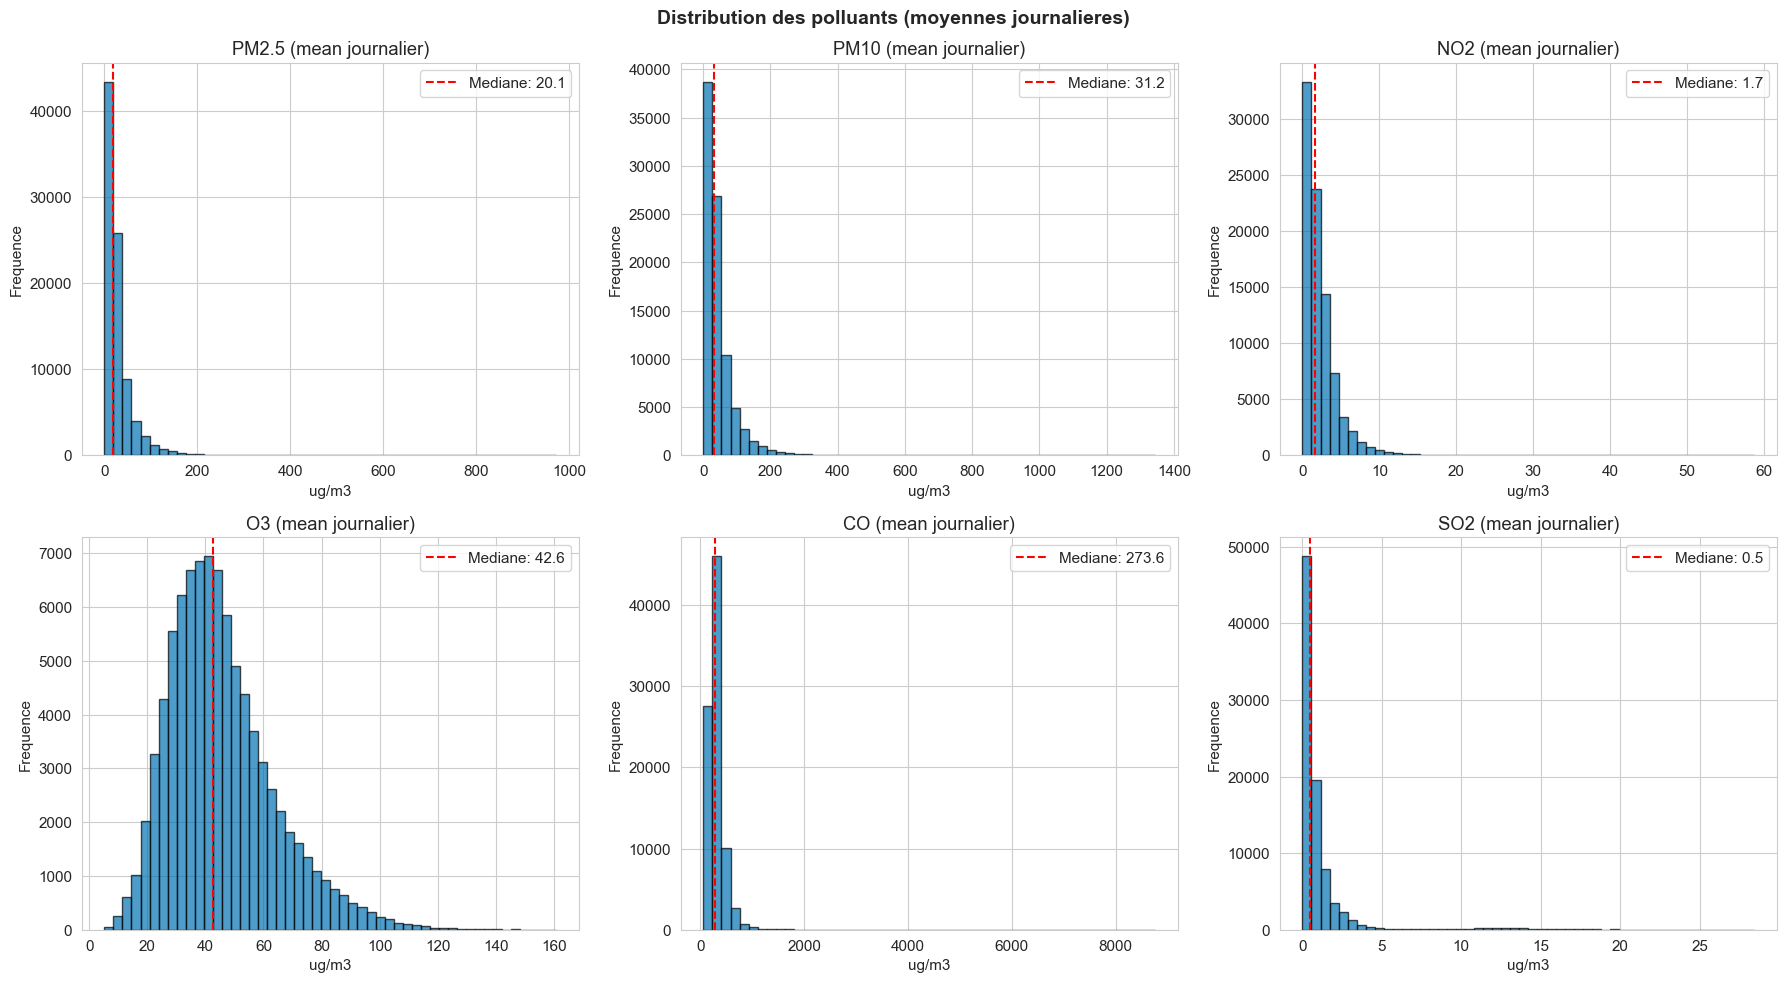

In [ ]:
## --- [SECTION 5] : Distribution des polluants --- ##

pollutants = ['pm2_5_mean', 'pm10_mean', 'no2_mean', 'o3_mean', 'co_mean', 'so2_mean']
pollutant_labels = ['PM2.5', 'PM10', 'NO2', 'O3', 'CO', 'SO2']
available = [(p, l) for p, l in zip(pollutants, pollutant_labels) if p in df_daily.columns]

n_plots = len(available)
n_cols = min(3, n_plots)
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
if n_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, (col, label) in enumerate(available):
    data = df_daily[col].dropna()
    axes[i].hist(data, bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{label} (mean journalier)')
    axes[i].set_xlabel('ug/m3')
    axes[i].set_ylabel('Frequence')
    axes[i].axvline(data.median(), color='red', linestyle='--', label=f'Mediane: {data.median():.1f}')
    axes[i].legend()

# Masquer les axes vides
for j in range(len(available), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des polluants (moyennes journalieres)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

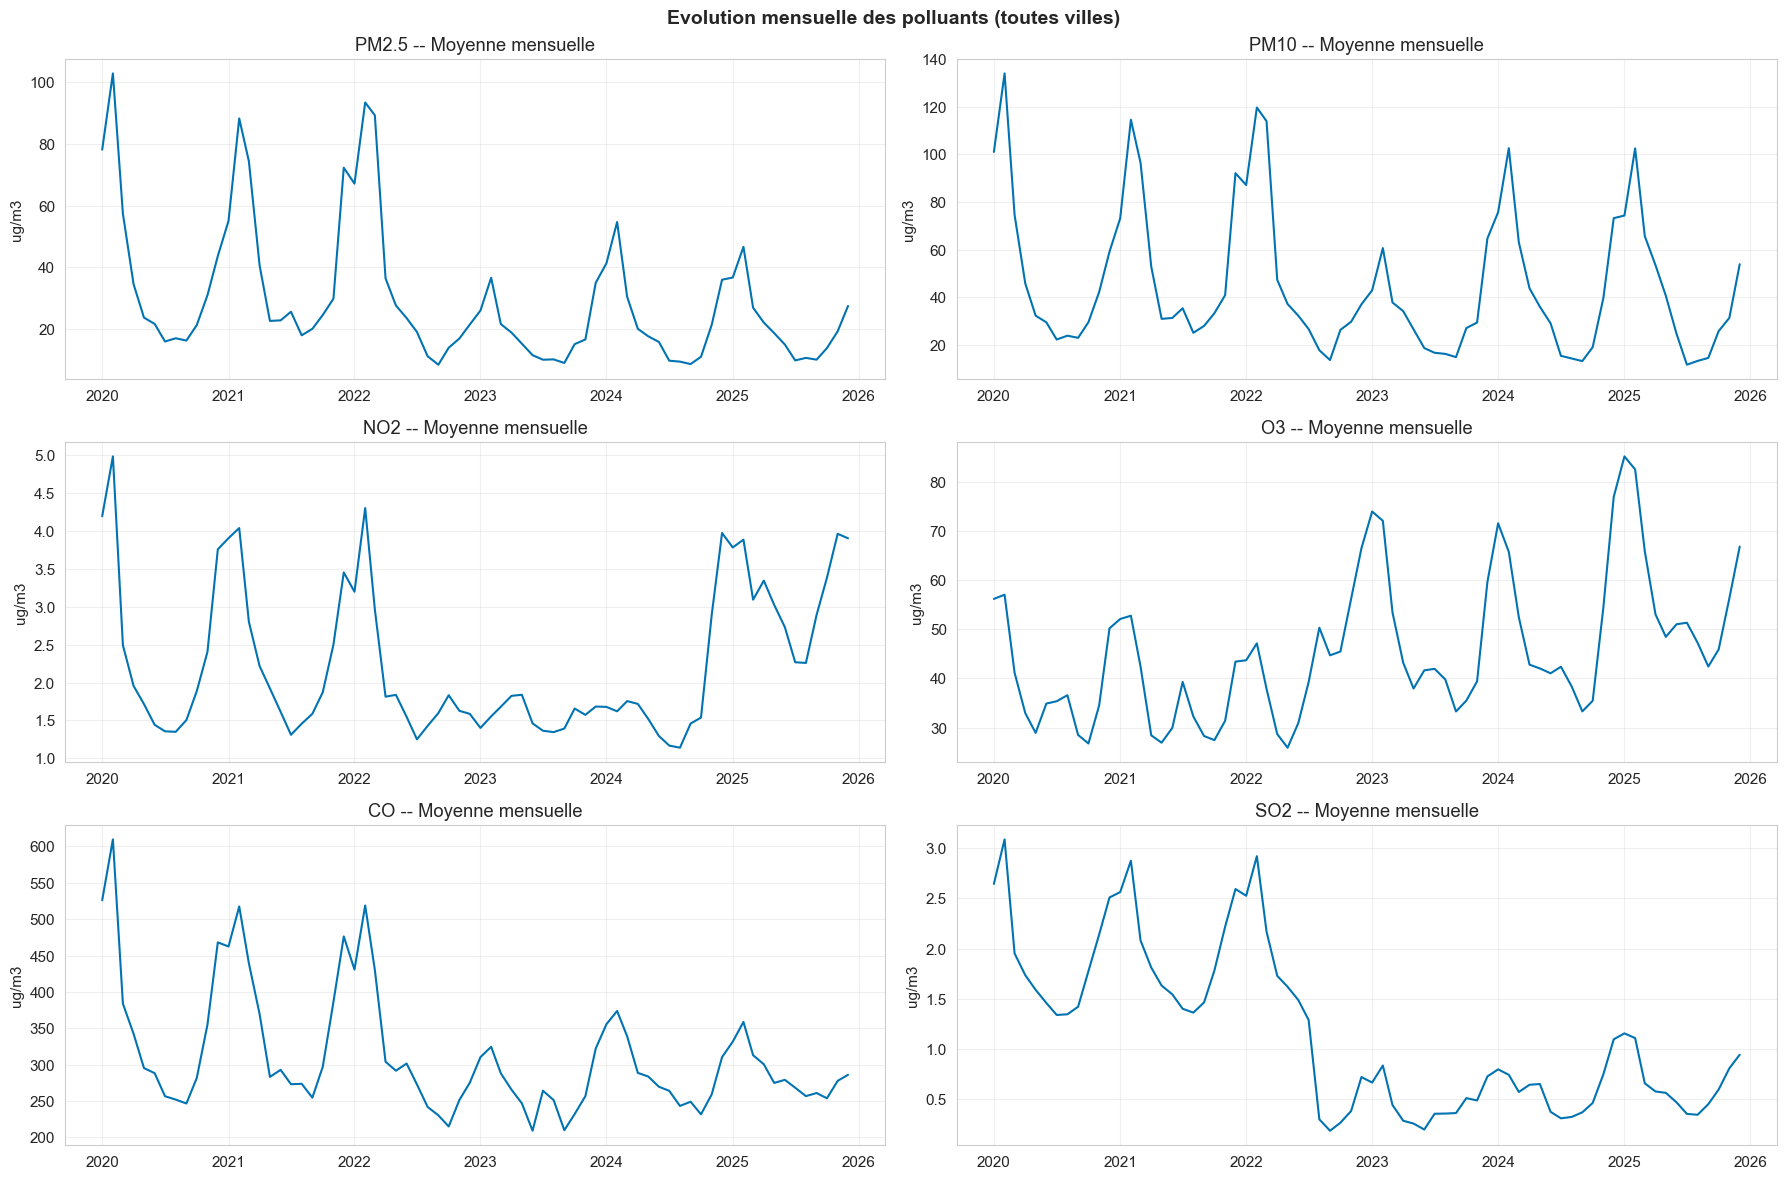

In [ ]:
## --- [SECTION 5] : Series temporelles mensuelles --- ##

df_daily['_month'] = df_daily['date'].dt.to_period('M')

n_plots = len(available)
n_cols = min(2, n_plots)
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
if n_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, (col, label) in enumerate(available):
    monthly = df_daily.groupby('_month')[col].mean()
    monthly.index = monthly.index.to_timestamp()
    axes[i].plot(monthly.index, monthly.values, linewidth=1.5)
    axes[i].set_title(f'{label} -- Moyenne mensuelle')
    axes[i].set_ylabel('ug/m3')
    axes[i].grid(True, alpha=0.3)

for j in range(len(available), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Evolution mensuelle des polluants (toutes villes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

df_daily.drop(columns=['_month'], inplace=True)

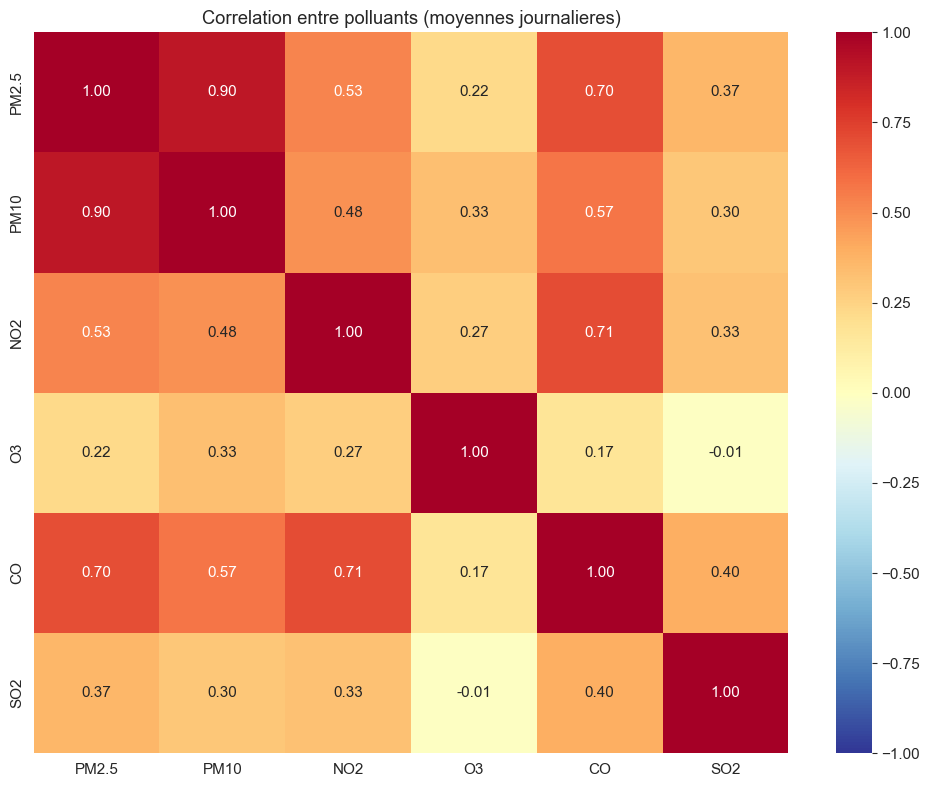

In [ ]:
## --- [SECTION 5] : Matrice de correlation entre polluants --- ##

corr_cols = [col for col, _ in available]
corr_labels = [label for _, label in available]

if len(corr_cols) > 1:
    corr_matrix = df_daily[corr_cols].corr()
    corr_matrix.index = corr_labels
    corr_matrix.columns = corr_labels

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
                center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title('Correlation entre polluants (moyennes journalieres)')
    plt.tight_layout()
    plt.show()

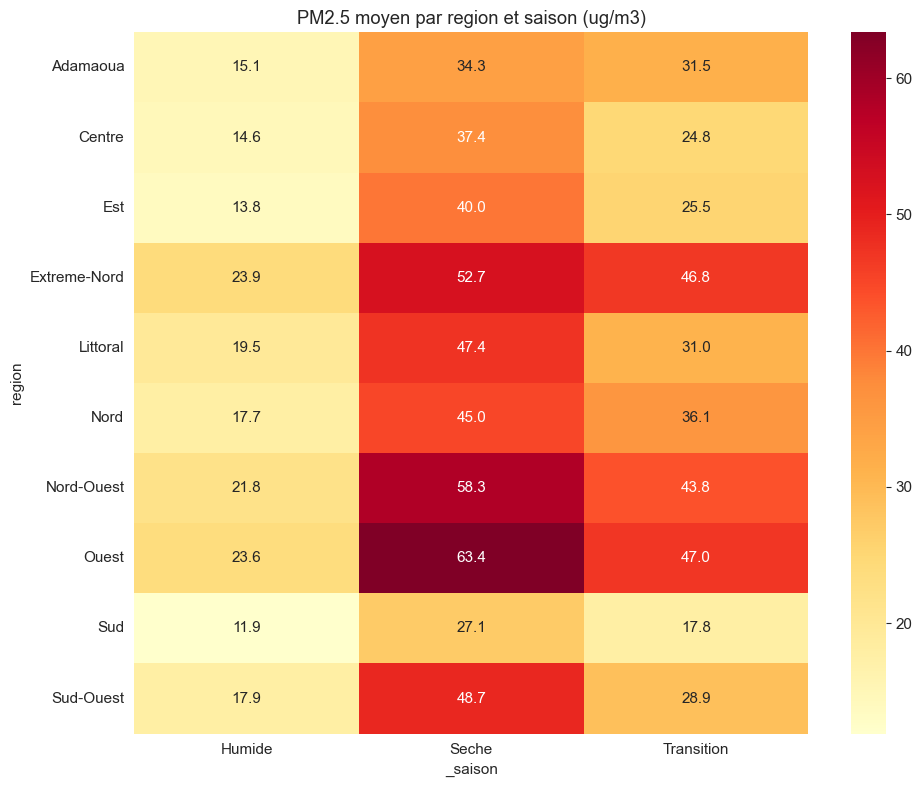

In [ ]:
## --- [SECTION 5] : PM2.5 moyen par region et saison --- ##

df_daily['_annee'] = df_daily['date'].dt.year
df_daily['_saison'] = df_daily['date'].dt.month.map({
    1: 'Seche', 2: 'Seche', 3: 'Transition',
    4: 'Humide', 5: 'Humide', 6: 'Humide',
    7: 'Humide', 8: 'Humide', 9: 'Humide',
    10: 'Transition', 11: 'Seche', 12: 'Seche'
})

pivot = df_daily.pivot_table(values='pm2_5_mean', index='region', columns='_saison', aggfunc='mean')
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
ax.set_title('PM2.5 moyen par region et saison (ug/m3)')
plt.tight_layout()
plt.show()

# Nettoyage colonnes temporaires
df_daily.drop(columns=['_annee', '_saison'], inplace=True)

## SECTION 6 -- EXPORT FINAL

Sauvegarde du dataset de qualite de l'air en formats Parquet et CSV.

In [ ]:
## --- [SECTION 6] : Preparation du fichier final --- ##

# Colonnes polluants (concentrations)
cols_polluants = []
for var_short in AQ_SHORT_NAMES.values():
    for suffix in ['_mean', '_max', '_p75']:
        col = f'{var_short}{suffix}'
        if col in df_daily.columns:
            cols_polluants.append(col)

# Colonnes sous-AQI
cols_sub_aqi = ['aqi_pm2_5', 'aqi_pm10', 'aqi_o3', 'aqi_no2', 'aqi_co', 'aqi_so2']

cols_final = (
    ['city', 'date']
    + cols_polluants
    + ['n_heures_valides', 'pm25_categorie', 'pm25_depasse_oms',
       'aqi', 'aqi_categorie', 'aqi_polluant_dominant']
    + cols_sub_aqi
    + ['aqi_methode', 'region', 'source']
)
cols_present = [c for c in cols_final if c in df_daily.columns]
df_final = df_daily[cols_present].copy()

# Renommer date -> time pour coherence avec le dataset meteo
df_final = df_final.rename(columns={'date': 'time'})

# Tri et deduplication
df_final = df_final.sort_values(['city', 'time']).reset_index(drop=True)
n_dup = df_final.duplicated(subset=['city', 'time']).sum()
if n_dup > 0:
    logger.warning(f'{n_dup} doublons supprimes.')
    df_final = df_final.drop_duplicates(subset=['city', 'time'], keep='first')

logger.info(f'df_final.shape : {df_final.shape}')
logger.info(f'Colonnes : {list(df_final.columns)}')
logger.info(f'Periode : {df_final["time"].min()} a {df_final["time"].max()}')
print('\n--- Apercu ---')
print(df_final.head(10).to_string())
print('\n--- Stats ---')
print(df_final.describe().round(2).to_string())

In [ ]:
## --- [SECTION 6] : Export --- ##

# Parquet
parquet_path = OUTPUT_DIR / 'air_quality_targets.parquet'
df_final.to_parquet(parquet_path, index=False)
logger.info(f'[OK] Sauvegarde Parquet : {parquet_path} ({parquet_path.stat().st_size / 1e6:.1f} Mo)')

# CSV compresse
csv_gz_path = OUTPUT_DIR / 'air_quality_targets.csv.gz'
df_final.to_csv(csv_gz_path, index=False, compression='gzip')
logger.info(f'[OK] Sauvegarde CSV.gz : {csv_gz_path} ({csv_gz_path.stat().st_size / 1e6:.1f} Mo)')

# CSV simple
csv_path = OUTPUT_DIR / 'air_quality_targets.csv'
df_final.to_csv(csv_path, index=False)
logger.info(f'[OK] Sauvegarde CSV : {csv_path} ({csv_path.stat().st_size / 1e6:.1f} Mo)')

10:48:56 [INFO] [OK] Sauvegarde Parquet : c:\Users\NICK-TECH\OneDrive\Desktop\HACKATHON-INDABAX-CAMEROON-2026\HACKATHON-INDABAX-CAMEROON-2026\data\air_quality_targets.parquet (7.1 Mo)
10:49:02 [INFO] [OK] Sauvegarde CSV.gz : c:\Users\NICK-TECH\OneDrive\Desktop\HACKATHON-INDABAX-CAMEROON-2026\HACKATHON-INDABAX-CAMEROON-2026\data\air_quality_targets.csv.gz (8.6 Mo)
10:49:06 [INFO] [OK] Sauvegarde CSV : c:\Users\NICK-TECH\OneDrive\Desktop\HACKATHON-INDABAX-CAMEROON-2026\HACKATHON-INDABAX-CAMEROON-2026\data\air_quality_targets.csv (27.1 Mo)


In [ ]:
## --- [SECTION 6] : Rapport de collecte --- ##

villes_collectees = df_final['city'].unique().tolist()
villes_manquantes = [v for v in VILLES if v not in villes_collectees]

report = {
    'date_generation': datetime.now().isoformat(),
    'periode': {'debut': DATE_START, 'fin': DATE_END},
    'polluants': list(AQ_SHORT_NAMES.values()),
    'sources': {
        'principale': 'Open-Meteo Air Quality API',
        'complement': 'CAMS EAC4 (Copernicus ADS)' if CAMS_AVAILABLE else 'Non disponible',
    },
    'villes_collectees': len(villes_collectees),
    'villes_manquantes': villes_manquantes,
    'nb_lignes': len(df_final),
    'nb_colonnes': len(df_final.columns),
    'colonnes': list(df_final.columns),
    'couverture_par_polluant': {
        var: float(df_final[f'{var}_mean'].notna().mean() * 100)
        for var in AQ_SHORT_NAMES.values()
        if f'{var}_mean' in df_final.columns
    },
    'repartition_sources': df_final['source'].value_counts().to_dict() if 'source' in df_final.columns else {},
}

report_path = OUTPUT_DIR / 'collection_report.json'
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2, ensure_ascii=False, default=str)

logger.info(f'[OK] Rapport sauvegarde : {report_path}')
print(json.dumps(report, indent=2, ensure_ascii=False, default=str))

10:49:06 [INFO] [OK] Rapport sauvegarde : c:\Users\NICK-TECH\OneDrive\Desktop\HACKATHON-INDABAX-CAMEROON-2026\HACKATHON-INDABAX-CAMEROON-2026\data\collection_report.json


{
  "date_generation": "2026-03-25T10:49:06.166681",
  "periode": {
    "debut": "2020-01-01",
    "fin": "2025-12-31"
  },
  "polluants": [
    "pm2_5",
    "pm10",
    "no2",
    "o3",
    "co",
    "so2"
  ],
  "sources": {
    "principale": "Open-Meteo Air Quality API",
    "complement": "CAMS EAC4 (Copernicus ADS)"
  },
  "villes_collectees": 40,
  "villes_manquantes": [],
  "nb_lignes": 87680,
  "nb_colonnes": 28,
  "colonnes": [
    "city",
    "time",
    "pm2_5_mean",
    "pm2_5_max",
    "pm2_5_p75",
    "pm10_mean",
    "pm10_max",
    "pm10_p75",
    "no2_mean",
    "no2_max",
    "no2_p75",
    "o3_mean",
    "o3_max",
    "o3_p75",
    "co_mean",
    "co_max",
    "co_p75",
    "so2_mean",
    "so2_max",
    "so2_p75",
    "n_heures_valides",
    "pm25_categorie",
    "pm25_depasse_oms",
    "aqi",
    "aqi_categorie",
    "aqi_polluant_dominant",
    "region",
    "source"
  ],
  "couverture_par_polluant": {
    "pm2_5": 100.0,
    "pm10": 100.0,
    "no2": 100.0,
    "o

### Recapitulatif et prochaines etapes

Ce notebook a collecte les donnees de qualite de l'air pour les 42 villes camerounaises :

| Element | Detail |
|---------|--------|
| **Periode** | 2020-01-01 a 2025-12-31 |
| **Source principale** | Open-Meteo Air Quality API |
| **Source complement** | CAMS EAC4 (Copernicus ADS) |
| **Polluants** | PM2.5, PM10, NO2, O3, CO, SO2 |
| **Granularite** | Journaliere (agrege depuis horaire) |
| **Fichier de sortie** | `data/air_quality_targets.parquet` |

**Prochaines etapes :**
1. Jointure avec le dataset meteorologique nettoye (`data_clean.parquet`) sur `city` et `time`
2. Feature engineering croise (meteo x pollution)
3. Modelisation predictive

In [ ]:
logger.info('[OK] Section 6 terminee.')
print('[OK] Notebook 02 termine -- variables cibles pretes (2020-2025).')
print(f'  Polluants : PM2.5, PM10, NO2, O3, CO, SO2')
print(f'  Fichier : data/air_quality_targets.parquet ({len(df_final)} lignes)')

10:49:06 [INFO] [OK] Section 6 terminee.


[OK] Notebook 02 termine -- variables cibles pretes (2020-2025).
  Polluants : PM2.5, PM10, NO2, O3, CO, SO2
  Fichier : data/air_quality_targets.parquet (87680 lignes)
